In [1]:
import os, time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Input, Resizing, GlobalAveragePooling2D, Dense,
                                     Conv2D, AveragePooling2D, MaxPooling2D,
                                     Flatten, Dropout, BatchNormalization)
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available:", len(gpus))
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

os.makedirs("plots", exist_ok=True)
matplotlib.rcParams['font.weight'] = 'bold'
matplotlib.rcParams['axes.labelweight'] = 'bold'
matplotlib.rcParams['axes.titleweight'] = 'bold'

def save_plot(fig, filename):
    fig.savefig(os.path.join("plots", filename), dpi=600, bbox_inches='tight')
    plt.show()

NUM_CLASSES = 10
INPUT_SHAPE = (32, 32, 3)
BATCH_SIZE = 32
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

Num GPUs Available: 1


Training set   : (45000, 32, 32, 3) (45000, 10)
Validation set : (5000, 32, 32, 3) (5000, 10)
Testing set    : (10000, 32, 32, 3) (10000, 10)


/var/folders/0y/zlm89xcn0tqgwsy072bpn4bc0000gn/T/ipykernel_5183/3384286079.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(class_names[int(y_train_labels[i])], fontweight='bold')


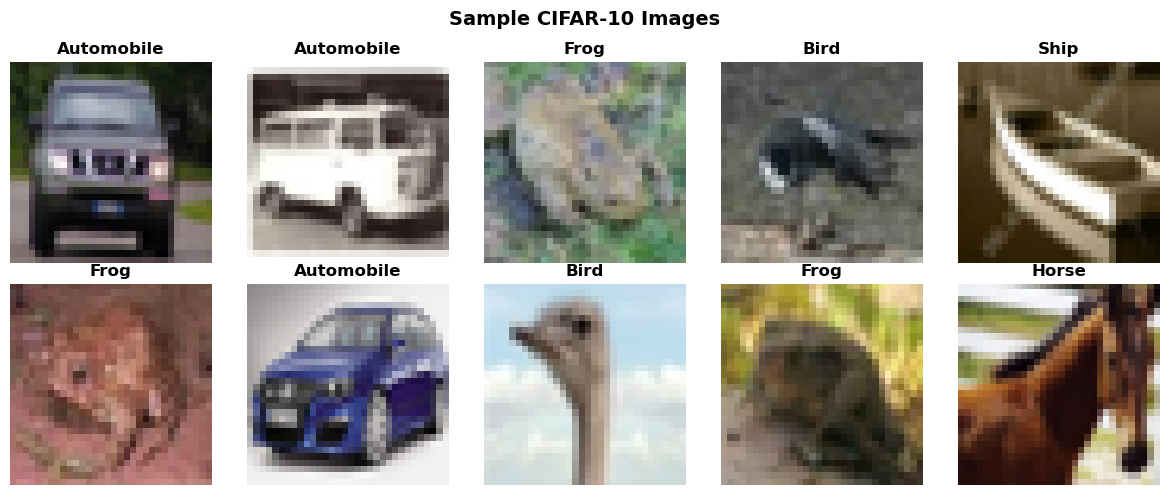

In [2]:
# 1. Load the CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 2. Normalize pixel values to [0, 1]
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Hold out 10% for validation so validation metrics are independent of the test set
x_train, x_val, y_train_labels, y_val_labels = train_test_split(
    x_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full)

y_train = to_categorical(y_train_labels, NUM_CLASSES)
y_val = to_categorical(y_val_labels, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)
y_true = y_test.flatten()

# 4. Print the dimensions of the training and testing datasets
print("Training set   :", x_train.shape, y_train.shape)
print("Validation set :", x_val.shape, y_val.shape)
print("Testing set    :", x_test.shape, y_test_cat.shape)

# 3. Display ten sample images                                    [Plot 1]
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample CIFAR-10 Images", fontweight='bold', fontsize=14)
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[int(y_train_labels[i])], fontweight='bold')
    ax.axis('off')
plt.tight_layout()
save_plot(fig, "plot1_sample_images.png")

In [3]:
def build_transfer_model(base_fn, dense_units=128, learning_rate=0.001,
                         optimizer_name='adam', size=32, freeze='all'):
    # 1 & 2. Pretrained ImageNet weights, original classification layer removed
    base = base_fn(weights='imagenet', include_top=False, input_shape=(size, size, 3))
    # 3. Freeze the convolutional base
    if freeze == 'all':
        base.trainable = False
    else:                                    # partial: last conv block only
        base.trainable = True
        for layer in base.layers:
            layer.trainable = layer.name.startswith('block5')

    inputs = Input(shape=INPUT_SHAPE)
    x = Resizing(size, size)(inputs) if size != 32 else inputs
    x = base(x)
    x = GlobalAveragePooling2D()(x)                          # 4. GAP layer
    x = Dense(dense_units, activation='relu')(x)             # 5. Dense + ReLU
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)    # 6. Softmax output
    model = Model(inputs, outputs)

    opt = Adam(learning_rate=learning_rate) if optimizer_name == 'adam' \
          else SGD(learning_rate=learning_rate, momentum=0.9)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model, base

vgg_model, vgg_base = build_transfer_model(VGG16)
vgg_model.summary()

2026-08-19 08:29:28.569510: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-08-19 08:29:28.569562: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-19 08:29:28.569577: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1787142568.570633 8457118 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1787142568.572641 8457118 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [4]:
EPOCHS_MAIN = 15

start = time.time()
history = vgg_model.fit(x_train, y_train,
                        validation_data=(x_val, y_val),
                        batch_size=BATCH_SIZE, epochs=EPOCHS_MAIN, verbose=1)
vgg_train_time = time.time() - start
print(f"Frozen-base training time: {vgg_train_time:.2f} s")

Epoch 1/15


2026-08-19 08:29:31.390036: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
E0000 00:00:1787142571.395812 8457118 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.4536 - loss: 1.5581 - val_accuracy: 0.5846 - val_loss: 1.2241
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.5775 - loss: 1.1998 - val_accuracy: 0.5946 - val_loss: 1.1861
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.6033 - loss: 1.1348 - val_accuracy: 0.6004 - val_loss: 1.1489
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.6150 - loss: 1.0930 - val_accuracy: 0.6092 - val_loss: 1.1354
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.6278 - loss: 1.0651 - val_accuracy: 0.6068 - val_loss: 1.1245
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.6367 - loss: 1.0358 - val_accuracy: 0.6140 - val_loss: 1.1128
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.6479 - loss: 1.0009 - val_accuracy: 0.6160 - val_loss: 1.1050
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.6539 - loss: 0.98

In [5]:
# 1. Unfreeze the last convolution block
vgg_base.trainable = True
for layer in vgg_base.layers:
    layer.trainable = layer.name.startswith('block5')

# Lower learning rate so the pretrained filters are not destroyed
vgg_model.compile(optimizer=Adam(learning_rate=1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])

# 2. Train for another 8 epochs
EPOCHS_FINETUNE = 8
start = time.time()
history_ft = vgg_model.fit(x_train, y_train,
                           validation_data=(x_val, y_val),
                           batch_size=BATCH_SIZE, epochs=EPOCHS_FINETUNE, verbose=1)
vgg_finetune_time = time.time() - start

# 3. Compare accuracy before and after fine tuning    [Additional Exercise 4]
acc_before = history.history['val_accuracy'][-1]
acc_after = history_ft.history['val_accuracy'][-1]
print(f"\nFine-tuning time: {vgg_finetune_time:.2f} s")
print(f"Validation accuracy before fine tuning: {acc_before:.4f}")
print(f"Validation accuracy after  fine tuning: {acc_after:.4f}")
print(f"Improvement: {acc_after - acc_before:+.4f}")

Epoch 1/8


E0000 00:00:1787142915.338690 8457118 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.7192 - loss: 0.8019 - val_accuracy: 0.6732 - val_loss: 1.0032
Epoch 2/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.7801 - loss: 0.6298 - val_accuracy: 0.6772 - val_loss: 0.9967
Epoch 3/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.8216 - loss: 0.5190 - val_accuracy: 0.6952 - val_loss: 0.9514
Epoch 4/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.8517 - loss: 0.4411 - val_accuracy: 0.6936 - val_loss: 0.9611
Epoch 5/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.8759 - loss: 0.3770 - val_accuracy: 0.6992 - val_loss: 0.9726
Epoch 6/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.8989 - loss: 0.3148 - val_accuracy: 0.7050 - val_loss: 0.9759
Epoch 7/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.9171 - loss: 0.2647 - val_accuracy: 0.7074 - val_loss: 0.9976
Epoch 8/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.9365 - loss: 0.2194 - va

In [6]:
y_pred = np.argmax(vgg_model.predict(x_test), axis=1)

test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average='macro')
test_recall = recall_score(y_true, y_pred, average='macro')
test_f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Accuracy        : {test_accuracy:.4f}")
print(f"Precision (macro avg): {test_precision:.4f}")
print(f"Recall (macro avg)   : {test_recall:.4f}")
print(f"F1-score (macro avg) : {test_f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

  7/313 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step   

E0000 00:00:1787143216.492617 8457118 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Test Accuracy        : 0.7052
Precision (macro avg): 0.7058
Recall (macro avg)   : 0.7052
F1-score (macro avg) : 0.7044

Classification Report:

              precision    recall  f1-score   support

    Airplane       0.74      0.82      0.77      1000
  Automobile       0.81      0.77      0.79      1000
        Bird       0.67      0.60      0.64      1000
         Cat       0.52      0.53      0.52      1000
        Deer       0.66      0.64      0.65      1000
         Dog       0.62      0.59      0.61      1000
        Frog       0.68      0.80      0.74      1000
       Horse       0.76      0.75      0.75      1000
        Ship       0.81      0.82      0.81      1000
       Truck       0.79      0.73      0.76      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.70     10000
weighted avg       0.71      0.71      0.70     10000



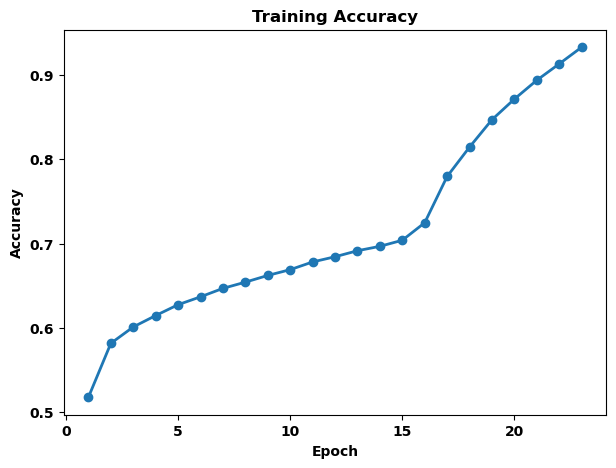

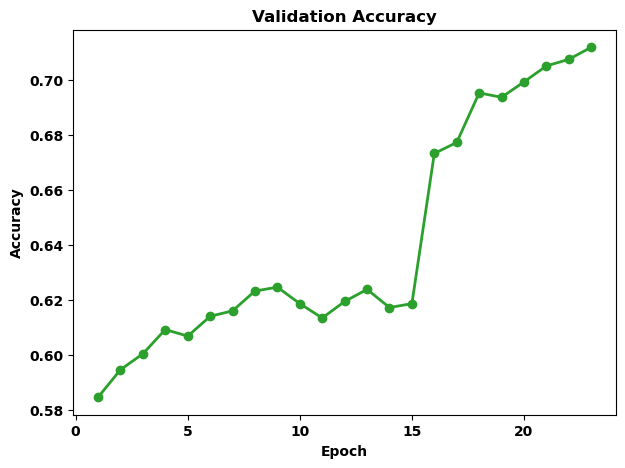

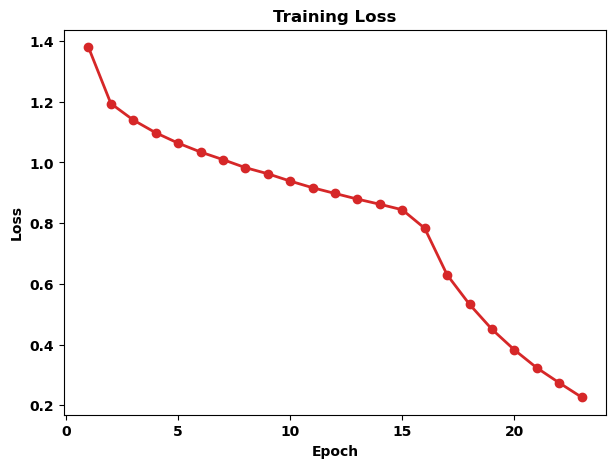

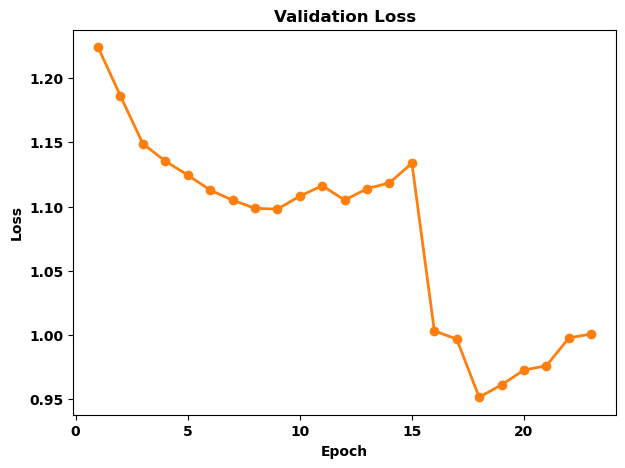

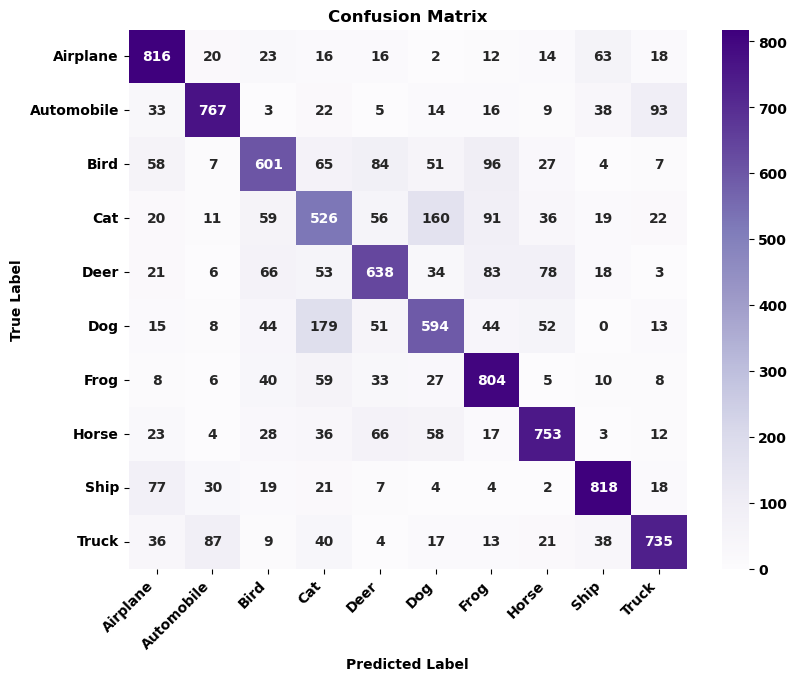

In [7]:
acc_tr  = history.history['accuracy']     + history_ft.history['accuracy']
acc_va  = history.history['val_accuracy'] + history_ft.history['val_accuracy']
loss_tr = history.history['loss']         + history_ft.history['loss']
loss_va = history.history['val_loss']     + history_ft.history['val_loss']
epochs_range = range(1, len(acc_tr) + 1)

for values, title, ylabel, colour, fname in [
    (acc_tr,  "Training Accuracy",   "Accuracy", '#1f77b4', "plot2_training_accuracy.png"),
    (acc_va,  "Validation Accuracy", "Accuracy", '#2ca02c', "plot3_validation_accuracy.png"),
    (loss_tr, "Training Loss",       "Loss",     '#d62728', "plot4_training_loss.png"),
    (loss_va, "Validation Loss",     "Loss",     '#ff7f0e', "plot5_validation_loss.png"),
]:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(epochs_range, values, marker='o', color=colour, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    save_plot(fig, fname)

# Confusion matrix                                                [Plot 6]
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
save_plot(fig, "plot6_confusion_matrix.png")

In [8]:
# Subset keeps 8 runs affordable. Set HP_N = len(x_train) for the full set.
HP_N = 10000
x_hp, y_hp = x_train[:HP_N], y_train[:HP_N]

def run_config(learning_rate=0.001, batch_size=32, epochs=10,
               optimizer_name='adam', dense_units=128, freeze='all'):
    tf.keras.backend.clear_session()
    m, _ = build_transfer_model(VGG16, dense_units=dense_units,
                                learning_rate=learning_rate,
                                optimizer_name=optimizer_name, freeze=freeze)
    hist = m.fit(x_hp, y_hp, validation_data=(x_val, y_val),
                 batch_size=batch_size, epochs=epochs, verbose=0)
    del m
    return hist.history['val_accuracy'][-1]

# One factor changed per run, everything else at baseline
configs = [
    ("Baseline",       {}),
    ("Learning Rate",  {'learning_rate': 0.0001}),
    ("Batch Size",     {'batch_size': 16}),
    ("Batch Size",     {'batch_size': 64}),
    ("Epochs",         {'epochs': 20}),
    ("Optimizer",      {'optimizer_name': 'sgd'}),
    ("Dense Units",    {'dense_units': 256}),
    ("Frozen Layers",  {'freeze': 'partial'}),
]

rows = []
for changed, cfg in configs:
    acc = run_config(**cfg)
    full = {'learning_rate': 0.001, 'batch_size': 32, 'epochs': 10,
            'optimizer_name': 'adam', 'dense_units': 128, 'freeze': 'all', **cfg}
    rows.append({'Changed': changed, **full, 'Val Accuracy': round(acc, 4)})
    print(f"{changed:<15} {cfg if cfg else 'defaults'} -> {acc:.4f}")

hp_df = pd.DataFrame(rows)
print("\nHyperparameter Study")
print(hp_df.to_string(index=False))

# Adam vs SGD                                     [Additional Exercise 3]
print(f"\nAdam: {rows[0]['Val Accuracy']:.4f}   SGD: {rows[5]['Val Accuracy']:.4f}")

Baseline        defaults -> 0.5640


E0000 00:00:1787143285.728395 8457118 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Learning Rate   {'learning_rate': 0.0001} -> 0.5440


E0000 00:00:1787143348.047989 8457118 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Batch Size      {'batch_size': 16} -> 0.5648


...

Optimizer       {'optimizer_name': 'sgd'} -> 0.5130


E0000 00:00:1787143716.586207 8457118 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Dense Units     {'dense_units': 256} -> 0.5778


E0000 00:00:1787143780.250872 8457118 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Frozen Layers   {'freeze': 'partial'} -> 0.6602

Hyperparameter Study
      Changed  learning_rate  batch_size  epochs optimizer_name  dense_units  freeze  Val Accuracy
     Baseline         0.0010          32      10           adam          128     all        0.5640
Learning Rate         0.0001          32      10           adam          128     all        0.5440
   Batch Size         0.0010          16      10           adam          128     all        0.5648
   Batch Size         0.0010          64      10           adam          128     all        0.5744
       Epochs         0.0010          32      20           adam          128     all        0.5658
    Optimizer         0.0010          32      10            sgd          128     all        0.5130
  Dense Units         0.0010          32      10           adam          256     all        0.5778
Frozen Layers         0.0010          32      10           adam          128 partial        0.6602

Adam: 0.5640   SGD: 0.5130


In [9]:
EPOCHS_OTHER = 10
transfer_results = {}

for name, fn, size in [("ResNet50", ResNet50, 32), ("GoogleNet", InceptionV3, 75)]:
    tf.keras.backend.clear_session()
    m, _ = build_transfer_model(fn, size=size)
    start = time.time()
    m.fit(x_train, y_train, validation_data=(x_val, y_val),
          batch_size=BATCH_SIZE, epochs=EPOCHS_OTHER, verbose=1)
    elapsed = time.time() - start
    pred = np.argmax(m.predict(x_test), axis=1)
    transfer_results[name] = {'params': m.count_params(),
                              'acc': accuracy_score(y_true, pred),
                              'time': elapsed}
    print(f"{name}: acc={transfer_results[name]['acc']:.4f}, "
          f"params={transfer_results[name]['params']:,}, time={elapsed:.1f}s")
    del m

Epoch 1/10


E0000 00:00:1787143885.373233 8457118 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 41ms/step - accuracy: 0.1940 - loss: 2.1809 - val_accuracy: 0.2640 - val_loss: 1.9862
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 54s 38ms/step - accuracy: 0.2984 - loss: 1.9238 - val_accuracy: 0.3148 - val_loss: 1.8646
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.3366 - loss: 1.8394 - val_accuracy: 0.3408 - val_loss: 1.8021
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - accuracy: 0.3465 - loss: 1.8084 - val_accuracy: 0.3572 - val_loss: 1.7588
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 54s 38ms/step - accuracy: 0.3562 - loss: 1.7849 - val_accuracy: 0.3510 - val_loss: 1.7856
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 53s 38ms/step - accuracy: 0.3610 - loss: 1.7618 - val_accuracy: 0.3450 - val_loss: 1.8152
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - accuracy: 0.3679 - loss: 1.7438 - val_accuracy: 0.3686 - val_loss: 1.7378
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 46s 33ms/step - accuracy: 0.3796 - loss: 1.73

E0000 00:00:1787144416.988663 8457118 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step
ResNet50: acc=0.3832, params=23,851,274, time=532.3s
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5113 - loss: 1.4134

E0000 00:00:1787144519.342179 8457118 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 92s 61ms/step - accuracy: 0.5114 - loss: 1.4133 - val_accuracy: 0.6212 - val_loss: 1.0947
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 50ms/step - accuracy: 0.6447 - loss: 1.0047 - val_accuracy: 0.6258 - val_loss: 1.0600
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 49ms/step - accuracy: 0.6915 - loss: 0.8816 - val_accuracy: 0.6306 - val_loss: 1.0795
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.7268 - loss: 0.7751 - val_accuracy: 0.6208 - val_loss: 1.1162
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.7699 - loss: 0.6608 - val_accuracy: 0.6138 - val_loss: 1.1608
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 71s 50ms/step - accuracy: 0.8013 - loss: 0.5682 - val_accuracy: 0.6210 - val_loss: 1.2196
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 71s 51ms/step - accuracy: 0.8366 - loss: 0.4830 - val_accuracy: 0.6076 - val_loss: 1.3051
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.8645 - loss: 0.40

E0000 00:00:1787145178.077615 8457118 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step
GoogleNet: acc=0.5973, params=22,066,346, time=741.5s


In [10]:
def build_lenet5():
    m = Sequential([
        Input(shape=INPUT_SHAPE),
        Conv2D(6, (5, 5), activation='tanh', padding='same'),
        AveragePooling2D((2, 2)),
        Conv2D(16, (5, 5), activation='tanh'),
        AveragePooling2D((2, 2)),
        Flatten(),
        Dense(120, activation='tanh'),
        Dense(84, activation='tanh'),
        Dense(NUM_CLASSES, activation='softmax'),
    ], name='LeNet5')
    m.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_alexnet():
    m = Sequential([
        Input(shape=INPUT_SHAPE),
        Conv2D(96, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(384, (3, 3), activation='relu', padding='same'),
        Conv2D(384, (3, 3), activation='relu', padding='same'),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(1024, activation='relu'),
        Dropout(0.5),
        Dense(1024, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax'),
    ], name='AlexNet')
    m.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

EPOCHS_SCRATCH = 10
scratch_results = {}

for name, builder in [('LeNet-5', build_lenet5), ('AlexNet', build_alexnet)]:
    tf.keras.backend.clear_session()
    m = builder()
    start = time.time()
    m.fit(x_train, y_train, validation_data=(x_val, y_val),
          batch_size=BATCH_SIZE, epochs=EPOCHS_SCRATCH, verbose=1)
    elapsed = time.time() - start
    pred = np.argmax(m.predict(x_test), axis=1)
    scratch_results[name] = {'params': m.count_params(),
                             'acc': accuracy_score(y_true, pred),
                             'time': elapsed}
    print(f"{name}: acc={scratch_results[name]['acc']:.4f}, time={elapsed:.1f}s")
    del m

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.3269 - loss: 1.8715 - val_accuracy: 0.4076 - val_loss: 1.6829
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.4516 - loss: 1.5517 - val_accuracy: 0.4840 - val_loss: 1.4662
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - accuracy: 0.5073 - loss: 1.3954 - val_accuracy: 0.4918 - val_loss: 1.4693
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.5281 - loss: 1.3223 - val_accuracy: 0.5286 - val_loss: 1.3583
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.5598 - loss: 1.2413 - val_accuracy: 0.5352 - val_loss: 1.3407
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 219s 155ms/step - accuracy: 0.5782 - loss: 1.1931 - val_accuracy: 0.5334 - val_loss: 1.3379
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.5998 - loss: 1.1306 - val_accuracy: 0.5344 - val_loss: 1.3405
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.6139

E0000 00:00:1787145706.828783 8457118 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
LeNet-5: acc=0.5329, time=506.6s
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3489 - loss: 1.7925

E0000 00:00:1787145788.243776 8457118 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 76s 50ms/step - accuracy: 0.3489 - loss: 1.7924 - val_accuracy: 0.4504 - val_loss: 1.5926
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.5524 - loss: 1.2612 - val_accuracy: 0.4980 - val_loss: 1.4569
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 46ms/step - accuracy: 0.6287 - loss: 1.0773 - val_accuracy: 0.5556 - val_loss: 1.2830
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.6634 - loss: 0.9927 - val_accuracy: 0.6592 - val_loss: 1.0150
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 48ms/step - accuracy: 0.6861 - loss: 0.9179 - val_accuracy: 0.6352 - val_loss: 1.0795
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 48ms/step - accuracy: 0.6959 - loss: 0.8939 - val_accuracy: 0.6140 - val_loss: 1.1564
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.7195 - loss: 0.8346 - val_accuracy: 0.6568 - val_loss: 1.0167
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 47ms/step - accuracy: 0.7285 - loss: 0.79

E0000 00:00:1787146387.661366 8457118 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
AlexNet: acc=0.6705, time=677.9s


In [11]:
print("=" * 60)
print("18.1 Performance Metrics - VGG16 (after fine tuning)")
print("=" * 60)
metrics_df = pd.DataFrame([
    ("Training Accuracy", f"{acc_tr[-1]:.4f}"),
    ("Testing Accuracy",  f"{test_accuracy:.4f}"),
    ("Precision",         f"{test_precision:.4f}"),
    ("Recall",            f"{test_recall:.4f}"),
    ("F1-score",          f"{test_f1:.4f}"),
    ("Training Time",     f"{vgg_train_time + vgg_finetune_time:.2f} s"),
    ("Total Parameters",  f"{vgg_model.count_params():,}"),
], columns=['Metric', 'Value'])
print(metrics_df.to_string(index=False))

print("\n" + "=" * 60)
print("18.2 Comparison of CNN Architectures")
print("=" * 60)
arch_df = pd.DataFrame([
    {'Model': 'LeNet-5',   **{'Parameters': scratch_results['LeNet-5']['params'],
     'Accuracy (%)': round(scratch_results['LeNet-5']['acc'] * 100, 2),
     'Training Time (s)': round(scratch_results['LeNet-5']['time'], 2)}},
    {'Model': 'AlexNet',   **{'Parameters': scratch_results['AlexNet']['params'],
     'Accuracy (%)': round(scratch_results['AlexNet']['acc'] * 100, 2),
     'Training Time (s)': round(scratch_results['AlexNet']['time'], 2)}},
    {'Model': 'VGG16',     **{'Parameters': vgg_model.count_params(),
     'Accuracy (%)': round(test_accuracy * 100, 2),
     'Training Time (s)': round(vgg_train_time + vgg_finetune_time, 2)}},
    {'Model': 'GoogleNet', **{'Parameters': transfer_results['GoogleNet']['params'],
     'Accuracy (%)': round(transfer_results['GoogleNet']['acc'] * 100, 2),
     'Training Time (s)': round(transfer_results['GoogleNet']['time'], 2)}},
    {'Model': 'ResNet50',  **{'Parameters': transfer_results['ResNet50']['params'],
     'Accuracy (%)': round(transfer_results['ResNet50']['acc'] * 100, 2),
     'Training Time (s)': round(transfer_results['ResNet50']['time'], 2)}},
])
print(arch_df.to_string(index=False))

18.1 Performance Metrics - VGG16 (after fine tuning)
           Metric      Value
Training Accuracy     0.9330
 Testing Accuracy     0.7052
        Precision     0.7058
           Recall     0.7052
         F1-score     0.7044
    Training Time   645.98 s
 Total Parameters 14,781,642

18.2 Comparison of CNN Architectures
    Model  Parameters  Accuracy (%)  Training Time (s)
  LeNet-5       83126         53.29             506.58
  AlexNet     8578314         67.05             677.86
    VGG16    14781642         70.52             645.98
GoogleNet    22066346         59.73             741.47
 ResNet50    23851274         38.32             532.30
